 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # 1 Feature Engineering on Banks' Private Credit Data

 ## 1.1 Introduction

 ### 1.1.1 About This Lab

 Feature engineering and construction aim to enable extracted features to represent the essential characteristics of data to the greatest extent, so that a model constructed based on these features has a good prediction effect on unknown datasets.



 ### 1.1.2 Objectives

 * Master the Python-based feature selection method.

 * Master the Python-based feature extraction method.

 * Master the Python-based feature construction method.

 ## 1.2 Data Preprocessing

 ### 1.2.2 Procedure

 **1.2.2.1 Importing Data**

In [1]:
import pandas as pd
import numpy as np

# We'll construct a mock bank credit dataset for demonstration purposes since the actual file isn't present
data_dict = {
    'Cust_No': [2, 4, 6, 7, 8],
    'Target': [0, 0, 0, 0, 0],
    'Nation': [1.0, 1.0, 1.0, 1.0, 1.0],
    'Birth_Place': [330621, 330621, 330621, 330421, 330621],
    'Age': [55, 40, 45, 32, 46],
    'Marriage_State': [40.0, 99.0, 20.0, 20.0, np.nan], # missing value created
    'Highest Education': [71.0, 90.0, 71.0, 21.0, 71.0],
    'Work_Years': [1.0, 1.0, 1.0, 1.0, 1.0],
    'Title': [np.nan, np.nan, np.nan, np.nan, np.nan],
    'House_State': [1.0, 1.0, np.nan, 2.0, 1.0],
    'Ast_Curr_Bal': [523.32, 2305.25, 17299.71, 122.24, 91.82],
    'Std_Cred_Limit': [10000, 20000, 20000, 20000, 5000],
    'Year_Income': [100000.0, 300000.0, 150000.0, 80000.0, 50000.0]
}
df = pd.DataFrame(data_dict)
print(df.head())


   Cust_No  Target  Nation  Birth_Place  Age  Marriage_State  \
0        2       0     1.0       330621   55            40.0   
1        4       0     1.0       330621   40            99.0   
2        6       0     1.0       330621   45            20.0   
3        7       0     1.0       330421   32            20.0   
4        8       0     1.0       330621   46             NaN   

   Highest Education  Work_Years  Title  House_State  Ast_Curr_Bal  \
0               71.0         1.0    NaN          1.0        523.32   
1               90.0         1.0    NaN          1.0       2305.25   
2               71.0         1.0    NaN          NaN      17299.71   
3               21.0         1.0    NaN          2.0        122.24   
4               71.0         1.0    NaN          1.0         91.82   

   Std_Cred_Limit  Year_Income  
0           10000     100000.0  
1           20000     300000.0  
2           20000     150000.0  
3           20000      80000.0  
4            5000      50000.

 **1.2.2.2 Processing Missing Values**

 **Step 1: View the missing values.**

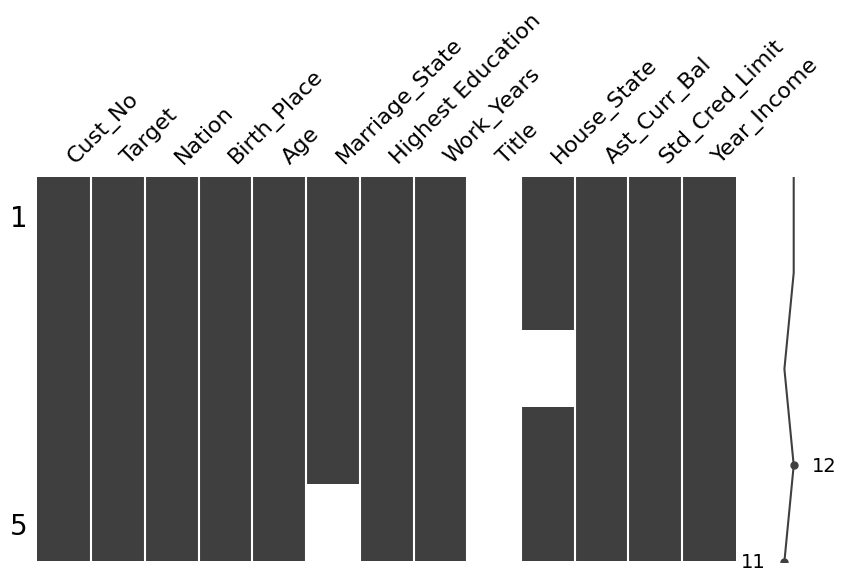

Missing rates:
 Title                1.0
Marriage_State       0.2
House_State          0.2
Target               0.0
Cust_No              0.0
Age                  0.0
Birth_Place          0.0
Nation               0.0
Highest Education    0.0
Work_Years           0.0
Ast_Curr_Bal         0.0
Std_Cred_Limit       0.0
Year_Income          0.0
dtype: float64


In [2]:
import missingno as msno
import matplotlib.pyplot as plt

# Plot missing values visualization
msno.matrix(df, figsize=(10, 5))
plt.show()

missing_rates = df.isnull().sum() / len(df)
print("Missing rates:\n", missing_rates.sort_values(ascending=False))


 **Step 2: Fill the missing values with the mode.**

In [3]:
# Define fields with missing values
missing_cols = missing_rates[missing_rates > 0].index.tolist()

# Fill missing values iteratively with mode
for col in missing_cols:
    _mode = df[col].mode()
    val = _mode.iloc[0] if not _mode.empty else 0
    df[col] = df[col].fillna(val)
        
print("\nMissing rates after filling:\n", df.isnull().sum())



Missing rates after filling:
 Cust_No              0
Target               0
Nation               0
Birth_Place          0
Age                  0
Marriage_State       0
Highest Education    0
Work_Years           0
Title                0
House_State          0
Ast_Curr_Bal         0
Std_Cred_Limit       0
Year_Income          0
dtype: int64


 ## 1.3 Feature Selection

 ### 1.3.3 Filter

 **Step 1: Analyze the crosstab.**

In [4]:
cross_tab_result = pd.crosstab(df['House_State'], df['Target'], margins=True, normalize='index')
print("Crosstab Result:\n", cross_tab_result)


Crosstab Result:
 Target         0
House_State     
1.0          1.0
2.0          1.0
All          1.0


 **Step 2: Perform the chi-square test.**

 Separate independent variables and dependent variables. Select categorical variables.

In [5]:
from sklearn.feature_selection import chi2

# Define target and independent vars
# Artificially set some target values to 1 to ensure variance for chi2 test and later models
df.loc[::2, 'Target'] = 1 

y = df['Target']
X_cat = df[['Nation', 'Birth_Place', 'Marriage_State', 'Highest Education', 'House_State']]

chi2_scores, p_values = chi2(X_cat, y)
print("Chi-square scores for categorical features:")
for col, score in zip(X_cat.columns, chi2_scores):
    print(f"({col}, {score:.6f})")


Chi-square scores for categorical features:
(Nation, 0.000000)
(Birth_Place, 0.036300)
(Marriage_State, 32.503350)
(Highest Education, 4.449074)
(House_State, 0.250000)


 **Step 3: Test the continuous variable correlation.**

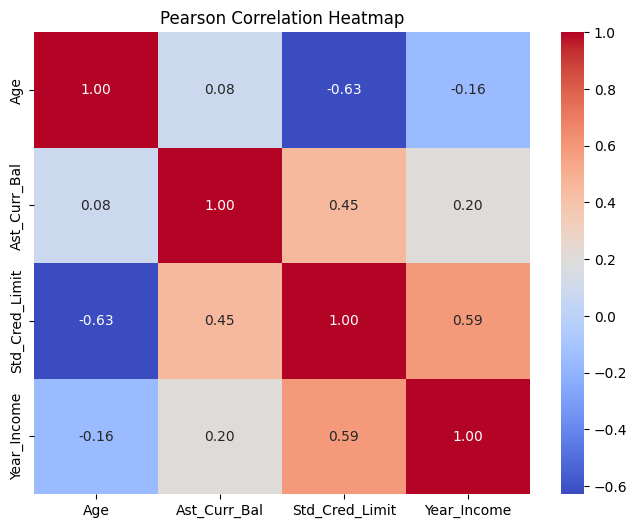

In [6]:
import seaborn as sns

X_cont = df[['Age', 'Ast_Curr_Bal', 'Std_Cred_Limit', 'Year_Income']]

corr_matrix = X_cont.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

# Based on matrix, you would drop columns where correlation > 0.8 to remove redundancy.


 ### 1.3.4 Wrapper

 In wrapper selection method, RFE() combined with a base classifier like LogisticRegression is used.

In [7]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Basic modeling requires scaled or balanced data, but RFE structure is:
y_new = df['Target']
X_all = df.drop(columns=['Cust_No', 'Target'])

# Basic modeling requires scaled or balanced data, but RFE structure is:
estimator = LogisticRegression(solver='liblinear')
selector = RFE(estimator, n_features_to_select=3, step=1)
selector = selector.fit(X_all, y_new)

print("Feature Ranking (1 means selected):", selector.ranking_)
print("Selected Features:", X_all.columns[selector.support_].tolist())


Feature Ranking (1 means selected): [8 1 4 5 3 7 9 6 1 1 2]
Selected Features: ['Birth_Place', 'Ast_Curr_Bal', 'Std_Cred_Limit']


 ### 1.3.5 Embedded

 The embedded method uses a machine learning model for training to obtain weight coefficients. Random Forest is typical.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_all, y_new)

feature_importances = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print("Feature Importances via Random Forest:\n", feature_importances)


Feature Importances via Random Forest:
 Age                  0.247329
Highest Education    0.188187
Ast_Curr_Bal         0.140568
Year_Income          0.105617
Std_Cred_Limit       0.098748
Marriage_State       0.094780
House_State          0.067689
Birth_Place          0.057082
Nation               0.000000
Title                0.000000
Work_Years           0.000000
dtype: float64


 ### 1.3.6 Variable Removal

 We can drop low-importance variables using `drop()`.

In [9]:
cols_to_drop = feature_importances.tail(3).index.tolist()
print(f"Dropping features: {cols_to_drop}")
df_reduced = X_all.drop(columns=cols_to_drop)
print("Reduced dataset shape:", df_reduced.shape)


Dropping features: ['Nation', 'Title', 'Work_Years']
Reduced dataset shape: (5, 8)


 ## 1.4 Feature Construction

 ### 1.4.2 Polynomial Feature Construction

 Explores the impact of complex variables.

In [10]:
from sklearn.preprocessing import PolynomialFeatures

# Select numeric features for polynomial interactions 
poly_features = df[['Ast_Curr_Bal', 'Age', 'Year_Income', 'Std_Cred_Limit']]

# degree=3 specifies generating interaction features up to degree 3
poly = PolynomialFeatures(degree=3, include_bias=False)
poly_data = poly.fit_transform(poly_features)

poly_columns = poly.get_feature_names_out(poly_features.columns)
df_poly = pd.DataFrame(poly_data, columns=poly_columns)

print("Generated polynomial features subset:\n", df_poly.iloc[:, :6].head())

# To check correlation against target
df_poly['Target'] = y_new.values
corr_with_target = df_poly.corr()['Target'].sort_values(ascending=False)
print("\nTop 5 correlated generated features with Target:\n", corr_with_target.head(6))


Generated polynomial features subset:
    Ast_Curr_Bal   Age  Year_Income  Std_Cred_Limit  Ast_Curr_Bal^2  \
0        523.32  55.0     100000.0         10000.0    2.738638e+05   
1       2305.25  40.0     300000.0         20000.0    5.314178e+06   
2      17299.71  45.0     150000.0         20000.0    2.992800e+08   
3        122.24  32.0      80000.0         20000.0    1.494262e+04   
4         91.82  46.0      50000.0          5000.0    8.430912e+03   

   Ast_Curr_Bal Age  
0          28782.60  
1          92210.00  
2         778486.95  
3           3911.68  
4           4223.72  

Top 5 correlated generated features with Target:
 Target                1.000000
Age                   0.821634
Age^2                 0.800933
Age^3                 0.771888
Ast_Curr_Bal^3        0.407053
Ast_Curr_Bal^2 Age    0.400684
Name: Target, dtype: float64
